# Stacked Ensemble

## **1. 스태킹 알고리즘**

여러 모델들을 활용해 각각의 예측 결과를 도출한 뒤 그 예측 결과를 결합해 최종 예측 결과를 만들어내는 것을 말한다.

따라서 스태킹 알고리즘에는 총 2가지 단계가 있는데 

- 단계 1. n 개의 모델로 학습 데이터로 학습 모델 생성
- 단계 2. n 개의 모델에서 학습을 마친 뒤 예측한 값들을 합쳐서 최종 예측

단계 1 과정에서 해당되는게 아래 그림의 Regression models 이고 단계 2 과정에 해당 되는게 Meta-regressor이다.

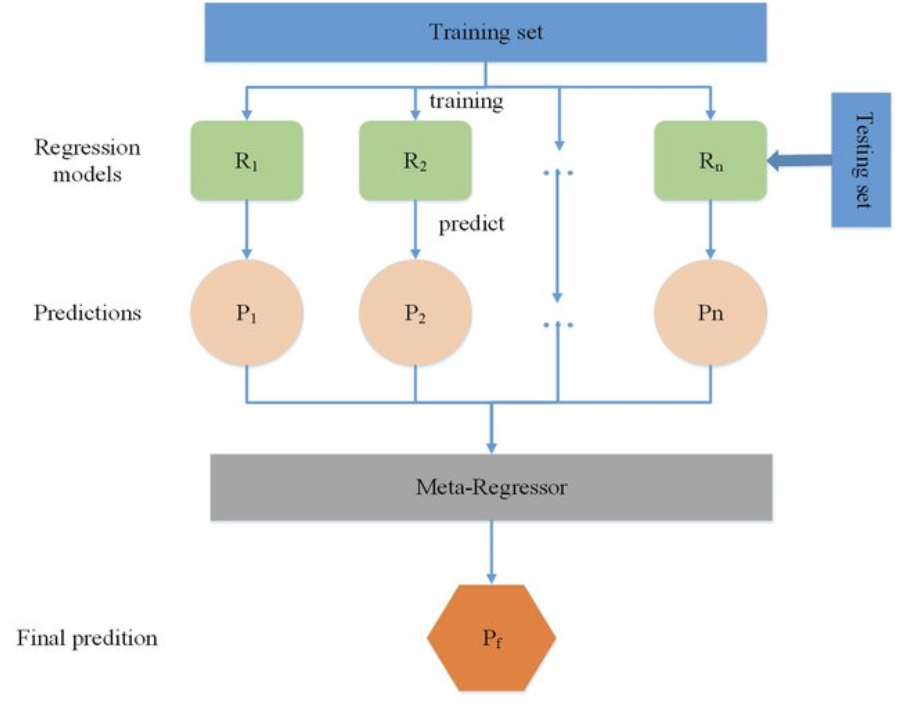

## 교차검증을 사용하지 않는 모댈

In [16]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [17]:
cancer_data = load_breast_cancer()

In [18]:
print(cancer_data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [19]:
X_data = cancer_data.data
y_label = cancer_data.target

In [20]:
X_training, X_testing, y_training, y_testing = train_test_split(X_data, y_label, test_size=0.2, random_state=0)

In [21]:
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

In [22]:
X_training.shape, X_testing.shape

((455, 30), (114, 30))

In [23]:
knn_clf.fit(X_training, y_training)
rf_clf.fit(X_training, y_training)
dt_clf.fit(X_training, y_training)
ada_clf.fit(X_training, y_training)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [24]:
knn_pred = knn_clf.predict(X_testing)
rf_pred = rf_clf.predict(X_testing)
dt_pred = dt_clf.predict(X_testing)
ada_pred = ada_clf.predict(X_testing)

In [25]:
print("KNN Accuracy: ", accuracy_score(y_testing, knn_pred))
print("Random Forest Accuracy: ", accuracy_score(y_testing, rf_pred))
print("Decision Tree Accuracy: ", accuracy_score(y_testing, dt_pred))
print("AdaBoost Accuracy: ", accuracy_score(y_testing, ada_pred))

KNN Accuracy:  0.9210526315789473
Random Forest Accuracy:  0.9649122807017544
Decision Tree Accuracy:  0.9122807017543859
AdaBoost Accuracy:  0.9736842105263158


## step 2. n개의 모델에서 학습을 마친 후 예측한 값들을 합쳐서 최종 예측

In [26]:

pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred])
print(pred.shape)

pred = np.transpose(pred)
print(pred.shape)

lr_final = LogisticRegression(C=10)
lr_final.fit(pred, y_testing)

final = lr_final.predict(pred)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(
    accuracy_score(y_testing, final)
))

(4, 114)
(114, 4)
최종 메타 모델의 예측 정확도: 0.9737


### 교차검증을 사용한 예제

In [27]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [28]:
cancer_data = load_breast_cancer()

In [30]:
X_data = cancer_data.data
y_label = cancer_data.target

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.2, random_state=0)

In [32]:
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(random_state=100)

In [38]:
lr_final_clf=LogisticRegression(C=10)

In [34]:
from sklearn.model_selection import KFold

In [35]:
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=0)
    train_fold_pred = np.zeros((X_train_n.shape[0], 1))
    test_pred = np.zeros((X_test_n.shape[0], n_folds))

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        X_tr = X_train_n[train_index]
        y_tr = y_train_n[train_index]
        X_vl = X_train_n[valid_index]
        
        model.fit(X_tr, y_tr)
        train_fold_pred[valid_index, :] = model.predict(X_vl).reshape(-1, 1)
        test_pred[:, folder_counter] = model.predict(X_test_n)
        
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)
    return train_fold_pred, test_pred_mean

![alt text](KakaoTalk_20260504_102908902.png)

In [36]:
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

In [37]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)

In [39]:
lr_final_clf.fit(Stack_final_X_train, y_train)

stack_final_pred = lr_final_clf.predict(Stack_final_X_test)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(
    accuracy_score(y_test, stack_final_pred)
))

최종 메타 모델의 예측 정확도: 0.9737
